In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import os
from typing import Optional, List, Tuple, Dict, Literal
from datetime import date
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy import stats
import holidays
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import timedelta
warnings.simplefilter("ignore")

from tabulate import tabulate

In [3]:
import pandas as pd
import numpy as np
import os
from datetime import date, datetime
import warnings
warnings.filterwarnings("ignore")
 
# ── PARAMETERS ──
input_csv     = r"C:\Users\RamanSharma\OneDrive - GNA-Energy\Desktop\ODISHA_LOAD_DATA\statewise_merit_generation_2025-10-01_2025-12-30.csv"
output_folder = r"C:\Users\RamanSharma\OneDrive - GNA-Energy\Desktop\data"
start_date    = '2025-07-03'   # only include data on or after this date
 
# Continuity check controls (big jumps)
DIFF_THRESHOLD = 600.0
STRICT_SPIKE   = True
CHECK_COLS     = ['total_drawal', 'isgs', 'importdata']  # auto-trim to those present
 
# Zero interpolation cutoff (HARD-CODED; set to None to disable)
ZERO_END_DATE  = "2025-10-08"   # ← set manually (YYYY-MM-DD) or None
ZERO_END_BLOCK = 96             # ← 1..96 or None
 
# ▼ NEW: Local drop smoother (handles “needles”)
DROP_WIN       = 13              # centered rolling window (must be odd); 9≈~34 min
DROP_DELTA_MW  = 800.0         # flag if (median - value) exceeds this absolute gap
DROP_FACTOR    = 1.00           # and value is below 70% of local median
MAX_CONSEC_N   = 4              # only “short” runs up to N are auto-smoothed
 
# ──────────────────────────────────────────────────────────────────────────────
def _smooth_spikes_one_day(s: pd.Series, thr: float, strict: bool) -> tuple[pd.Series, int]:
    vals = s.values.astype(float)
    n = len(vals)
    if n < 2:
        return s, 0
    bad = np.zeros(n, dtype=bool)
    if n >= 3:
        left  = np.abs(vals[1:-1] - vals[0:-2])
        right = np.abs(vals[2:]   - vals[1:-1])
        avg2  = (left + right) / 2.0
        if strict:
            mid_bad = (avg2 > thr) & (left > thr) & (right > thr)
        else:
            mid_bad = (avg2 > thr)
        bad[1:-1] = mid_bad
    if n >= 2:
        if np.abs(vals[1] - vals[0]) > thr: bad[0]  = True
        if np.abs(vals[-1] - vals[-2]) > thr: bad[-1] = True
    n_flagged = int(bad.sum())
    if n_flagged == 0:
        return s, 0
    fixed = vals.copy()
    fixed[bad] = np.nan
    fixed = pd.Series(fixed).interpolate(method='linear', limit_direction='both').values
    return pd.Series(fixed, index=s.index), n_flagged
 
def fix_continuity_spikes(df: pd.DataFrame, cols: list[str], thr: float, strict: bool,
                          date_col='date', block_col='time_block') -> tuple[pd.DataFrame, dict]:
    out = df.copy().sort_values([date_col, block_col]).reset_index(drop=True)
    counts = {c: 0 for c in cols}
    for c in cols: out[c] = out[c].astype(float)
    for c in cols:
        def _apply(g):
            fixed, n_bad = _smooth_spikes_one_day(g[c], thr, strict)
            counts[c] += n_bad
            g[c] = fixed.values
            return g
        out = out.groupby(date_col, group_keys=False).apply(_apply)
    return out, counts
 
# ▼ NEW: smooth short, deep local drops vs a rolling median “curve”
def _smooth_local_drops_one_day(s: pd.Series,
                                win: int, delta: float, factor: float,
                                max_consec: int) -> tuple[pd.Series, int]:
    x = s.astype(float).copy()
    # robust reference curve
    med = x.rolling(win, center=True, min_periods=1).median()
    gap = med - x
    # candidate dips: deep below local curve by absolute + relative tests
    cand = (gap > delta) & (x < factor * med)
 
    # only smooth short runs (to avoid flattening real valleys)
    if cand.any():
        # find run lengths
        idx = np.where(cand.values)[0]
        fix_mask = np.zeros_like(cand.values, dtype=bool)
        if idx.size:
            start = idx[0]; prev = idx[0]
            for i in idx[1:]+1:
                if i-1 != prev:
                    # close previous run
                    run = np.arange(start, prev+1)
                    if len(run) <= max_consec: fix_mask[run] = True
                    start = i-1
                prev = i-1
            # close last run
            run = np.arange(start, prev+1)
            if len(run) <= max_consec: fix_mask[run] = True
 
        n_fixed = int(fix_mask.sum())
        if n_fixed:
            x.values[fix_mask] = np.nan
            x = x.interpolate(method='linear', limit_direction='both')
            # if any NaNs remain at edges, carry nearest valid
            x = x.fillna(method='bfill').fillna(method='ffill')
            return x, n_fixed
    return x, 0
 
def smooth_local_drops(df: pd.DataFrame, cols: list[str],
                       win=DROP_WIN, delta=DROP_DELTA_MW, factor=DROP_FACTOR,
                       max_consec=MAX_CONSEC_N,
                       date_col='date', block_col='time_block') -> tuple[pd.DataFrame, dict]:
    out = df.copy().sort_values([date_col, block_col]).reset_index(drop=True)
    counts = {c: 0 for c in cols}
    for c in cols: out[c] = out[c].astype(float)
    for c in cols:
        def _apply(g):
            y, k = _smooth_local_drops_one_day(g[c], win, delta, factor, max_consec)
            counts[c] += k
            g[c] = y.values
            return g
        out = out.groupby(date_col, group_keys=False).apply(_apply)
    return out, counts
 
def interpolate_zeros_upto(df: pd.DataFrame,
                           cols: list[str],
                           end_date: date | None,
                           end_block: int | None,
                           date_col='date',
                           block_col='time_block') -> tuple[pd.DataFrame, dict]:
    out = df.copy().sort_values([date_col, block_col]).reset_index(drop=True)
    counts = {c: 0 for c in cols}
    if (end_date is None) or (end_block is None): return out, counts
    for c in cols: out[c] = out[c].astype(float)
    mask_before = out[date_col] < end_date
    mask_on     = (out[date_col] == end_date) & (out[block_col] <= end_block)
    eligible    = mask_before | mask_on
    for d, g in out.groupby(date_col, group_keys=False):
        day_idx = g.index
        for c in cols:
            s = out.loc[day_idx, c]
            elig_zero = eligible.loc[day_idx] & (s == 0.0)
            n_zero = int(elig_zero.sum())
            if n_zero == 0: continue
            nonzero_mask = (s != 0.0) & (~s.isna())
            if nonzero_mask.sum() == 0: continue
            s2 = s.copy()
            s2[elig_zero] = np.nan
            s2 = s2.interpolate(method='linear', limit_direction='both')
            s2 = s2.fillna(s)
            out.loc[day_idx, c] = s2.values
            counts[c] += n_zero
    return out, counts
 
# ── STEP 0: resolve zero-interp cutoff from constants ──
_end_date_val = None if ZERO_END_DATE is None else pd.to_datetime(ZERO_END_DATE)
_end_block_val = ZERO_END_BLOCK
 
# ── STEP 1: Read & clean ──
df = pd.read_csv(input_csv)
for col in ['demand_met', 'field_4_', 'own_generation', 'isgs', 'importdata']:
    if col in df.columns:
        df[col] = (df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True))
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)
 
# ── STEP 2: Parse dates & filter ──
df['date'] = pd.to_datetime(df['date'], errors='coerce')
start_dt = pd.to_datetime(start_date)
df = df[df['date'] >= start_dt]
 
# ── STEP 3: time_slot → block ──
times = pd.to_datetime(df['time_slot'].astype(str).str.strip(), format='%H:%M', errors='coerce')
df['time_block'] = (times.dt.hour * 4 + (times.dt.minute // 15) + 1).astype('Int64')
df = df.dropna(subset=['time_block'])
 
# ── STEP 4: 96-block template ──
all_blocks = pd.DataFrame({'time_block': np.arange(1, 97)})
os.makedirs(output_folder, exist_ok=True)
 
agg_input_cols = [c for c in ['demand_met', 'isgs', 'importdata'] if c in df.columns]
 
# ── STEP 5: by state ──
df = df[df["state"]=="Odisha"]
for state in df['state'].dropna().unique():
    state_df = df[df['state'] == state].copy()
 
    agg = (
        state_df
        .groupby(['date', 'time_block'], as_index=False)[agg_input_cols]
        .mean()
        .round(2)
    )
 
    dates_df = pd.DataFrame({'date': sorted(agg['date'].unique())})
    if dates_df.empty:
        print(f"✖ No data for {state} after {start_date}. Skipping.")
        continue
    dates_df['key'] = 1
    blocks_df = all_blocks.copy(); blocks_df['key'] = 1
    full = dates_df.merge(blocks_df, on='key').drop(columns='key')
 
    merged = full.merge(agg, on=['date', 'time_block'], how='left')
 
    rename_map = {}
    if 'demand_met' in merged.columns:
        rename_map['demand_met'] = 'total_drawal'
    out = merged.rename(columns=rename_map)
 
    if 'total_drawal' not in out.columns: out['total_drawal'] = 0.0
    for c in ['total_drawal', 'isgs', 'importdata']:
        if c in out.columns: out[c] = out[c].fillna(0.0)
 
    out = out.sort_values(['date', 'time_block']).reset_index(drop=True)
 
    # ── STEP 6: overrides ──
    july30 = date(2025, 7, 30); july31 = date(2025, 7, 31); aug1 = date(2025, 8, 1)
    cols_to_override = [c for c in ['total_drawal', 'isgs', 'importdata'] if c in out.columns]
    applied_overrides = {'2025-07-31_83-96': 0, '2025-08-01_1-31': 0}
    if cols_to_override:
        src_30 = out.loc[(out['date'] == july30) & (out['time_block'].between(83, 96)),
                         ['time_block'] + cols_to_override]
        if not src_30.empty:
            src_map = src_30.set_index('time_block')[cols_to_override]
            for tb, vals in src_map.iterrows():
                tgt = (out['date'] == july31) & (out['time_block'] == tb)
                if tgt.any():
                    out.loc[tgt, cols_to_override] = vals.values
                    applied_overrides['2025-07-31_83-96'] += 1
        src_31 = out.loc[(out['date'] == july31) & (out['time_block'].between(1, 31)),
                         ['time_block'] + cols_to_override]
        if not src_31.empty:
            src_map = src_31.set_index('time_block')[cols_to_override]
            for tb, vals in src_map.iterrows():
                tgt = (out['date'] == aug1) & (out['time_block'] == tb)
                if tgt.any():
                    out.loc[tgt, cols_to_override] = vals.values
                    applied_overrides['2025-08-01_1-31'] += 1
 
    # ── STEP 6.5: fixes in order ──
    cols_to_fix = [c for c in CHECK_COLS if c in out.columns]
 
    # 1) big two-sided jump spikes
    out, fix_counts = fix_continuity_spikes(out, cols_to_fix, DIFF_THRESHOLD, STRICT_SPIKE)
 
    # 2) zeros up to cutoff
    out, zero_counts = interpolate_zeros_upto(out, cols_to_fix, _end_date_val, _end_block_val)
 
    # 3) ▼ NEW: short local drop “needles”
    out, drop_counts = smooth_local_drops(out, cols_to_fix,
                                          win=DROP_WIN, delta=DROP_DELTA_MW,
                                          factor=DROP_FACTOR, max_consec=MAX_CONSEC_N)
 
    # ── STEP 7: save ──
    fname = state.strip().replace(' ', '_') + ".csv"
    out_path = os.path.join(output_folder, fname)
    out.to_csv(out_path, index=False)
 
    # log
    fixes_str = ", ".join([f"{k}={v}" for k, v in fix_counts.items()]) if fix_counts else "none"
    zeros_str = ", ".join([f"{k}={v}" for k, v in zero_counts.items()]) if zero_counts else "none"
    drops_str = ", ".join([f"{k}={v}" for k, v in drop_counts.items()]) if drop_counts else "none"
    cutoff_str = (f"zero_interp_upto={_end_date_val}#{_end_block_val}"
                  if (_end_date_val and _end_block_val) else "zero_interp_upto=disabled")
    print(
        f"✔ Saved {len(out)} rows for {state} → {out_path} | "
        f"Overrides: 31Jul[83-96]={applied_overrides['2025-07-31_83-96']}, "
        f"01Aug[1-31]={applied_overrides['2025-08-01_1-31']} | "
        f"Continuity spikes: {fixes_str} | Zeros: {zeros_str} | "
        f"Local-drop fixes: {drops_str} | {cutoff_str}"
    )

✔ Saved 8736 rows for Odisha → C:\Users\RamanSharma\OneDrive - GNA-Energy\Desktop\data\Odisha.csv | Overrides: 31Jul[83-96]=0, 01Aug[1-31]=0 | Continuity spikes: total_drawal=70 | Zeros: total_drawal=4 | Local-drop fixes: total_drawal=0 | zero_interp_upto=2025-10-08 00:00:00#96


In [2]:
# df = pd.read_csv(r"C:\Users\RamanSharma\OneDrive - GNA-Energy\Desktop\data\Odisha.csv") 
df = pd.read_csv(r"C:\Users\RamanSharma\OneDrive - GNA-Energy\Desktop\data\Odisha.csv")
# lod = lod.rename()
df['date'] = pd.to_datetime(
    df['date'],
    errors='coerce',
    dayfirst=True,
    format='mixed'
)

# convert 1–96 block to minutes offset
df['datetime'] = (df['date']+ pd.to_timedelta((df['time_block'] - 1) * 15, unit='min'))
df = df.dropna()
df = df[['datetime', 'total_drawal']]
df = df.rename(columns={'total_drawal': 'demand'})
print(df.datetime.max())
print(df.datetime.min())
df.to_parquet(r"C:\Users\RamanSharma\OneDrive - GNA-Energy\Desktop\ODISHA_LOAD_DATA\Odisha.parquet")

2025-12-28 23:45:00
2025-10-01 00:00:00


In [74]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add temporal categorical features (weekend, night, peak, business hours).
    """
    df = df.copy()
    idx = df.index
    in_holidays = holidays.India()
    df["date"] = df.index.date
    df["hour"] = df.index.hour
    df["minute"] = df.index.minute
    df["day_of_week"] = df.index.dayofweek
    df["day_of_month"] = df.index.day
    df["month"] = df.index.month
    df["time_block"] = df["hour"] * 4 + (df["minute"] // 15)
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    df["is_holiday"] = idx.map(lambda x: int(x in in_holidays))

    # df["hour_sin"]  = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"]  = np.cos(2 * np.pi * df["hour"] / 24)

    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    df["block_sin"] = np.sin(2 * np.pi * df["time_block"] / 96)
    df["block_cos"] = np.cos(2 * np.pi * df["time_block"] / 96)

    df["is_peak_hour"] = df["hour"].isin([7, 8, 9, 18, 19, 20]).astype(int)
    df["is_night"] = df["hour"].isin([0, 1, 2, 3, 4, 5,6]).astype(int)
    df["is_business_hour"] = ((df["hour"] >= 9) & (df["hour"] <= 17)).astype(int)
    if 'temperature' in df.columns:
        df['temp_squared'] = df['temperature'] ** 2
        df['temp_cubed'] = df['temperature'] ** 3

    df['temperature_sin'] = df['temperature']*(np.sin(2 * np.pi * df["hour"] / 24))

    return df


def ensure_weather_cols(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure mandatory weather columns exist; if missing, fill with zeros.
    """
    df = df.copy()
    required = ["temperature", "humidity", "precipitation"]
    for col in required:
        if col not in df.columns:
            df[col] = 0.0
    return df


def add_features(df: pd.DataFrame, scale_weather: bool = False) -> pd.DataFrame:
    """
    Add engineered time-weather interaction features for load forecasting.
    Args:
        df: Input DataFrame indexed by datetime.
        scale_weather: Whether to z-scale weather variables for model stability.
    """
    df = df.copy()
    df = add_time_features(df)
    df = ensure_weather_cols(df)

    if scale_weather:
        scaler = StandardScaler()
        df[["temperature", "humidity", "precipitation"]] = scaler.fit_transform(
            df[["temperature", "humidity", "precipitation"]]
        )
    # df["temp_hour_interaction"] = df["temperature"] * df.index.hour
    df["temp_peak_interaction"] = df["temperature"] * df["is_peak_hour"]
    # df["humidity_temp_interaction"] = df["humidity"] * df["temperature"]
    df["precip_peak_interaction"] = df["precipitation"] * df["is_peak_hour"]

    df.fillna(0, inplace=True)
    return df

class LoadDataProcessor:
    """ETL processor for state-wise load demand data."""

    def __init__(self, load_path: str, state: str = "HARYANA"):
        """
        Initialize LoadDataProcessor.
        Args:
            load_path (str): Path to the load parquet file.
            state (str): State name to filter.
        """
        self.load_path = load_path
        self.state = state
        self.df: pd.DataFrame | None = None

    def load_and_process(self):
        """
        Load and preprocess state-wise load data from the new unified parquet file.
    
        Expected input columns:
            ['datetime', 'date', 'time', 'time_block', 'state',
             'demand_met', 'own_generation', 'import']
        """
        # df = pd.read_parquet(
        #     r"C:\Users\RamanSharma\OneDrive - GNA-Energy\Desktop\data\state_wise.parquet",
        #     columns=["datetime", "demand_met", "state"]
        # )
        df = pd.read_parquet(r"C:\Users\RamanSharma\OneDrive - GNA-Energy\Desktop\ODISHA_LOAD_DATA\Odisha.parquet")
        # df.reset_index(drop=True, inplace=True)

        # df = df[["datetime", "demand_met"]].rename(columns={"demand_met": "demand"})

        if not np.issubdtype(df["datetime"].dtype, np.datetime64):
            df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    
        df.dropna(subset=["datetime", "demand"], inplace=True)

        df["demand"] = pd.to_numeric(df["demand"], errors="coerce").fillna(method="ffill")

        df.set_index("datetime", inplace=True)

        load_series = df["demand"].copy()
    
        return load_series, df


class WeatherDataProcessor:
    """Weather ETL + Statistical Imputation Processor."""

    WEATHER_COLS = ['temperature_2m', 'relative_humidity_2m', 'apparent_temperature','precipitation']

    def __init__(self, weather_path: str, state: str = "HARYANA"):
        self.weather_path = weather_path
        self.state = state
        self.df: Optional[pd.DataFrame] = None

    def load_data(self) -> pd.DataFrame:
        """Load state weather data efficiently."""
        cols = ['state', 'location', 'date', 'time', 'type'] + self.WEATHER_COLS
        df = pd.read_parquet(self.weather_path, columns=cols, engine='pyarrow')
        df = df.loc[df["state"] == self.state].copy()
        self.df = df
        return df

    def prepare_datetime(self) -> None:
        """Construct robust datetime field."""
        df = self.df
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["time"] = df["time"].astype(str).str.strip()
        df["datetime"] = pd.to_datetime(df["date"].astype(str) + " " + df["time"], errors="coerce")
        df.dropna(subset=["datetime"], inplace=True)
        df.sort_values("datetime", inplace=True)
        self.df = df

    @staticmethod
    def remove_outliers_zscore(df: pd.DataFrame, cols: List[str], z_thresh: float = 3.5) -> pd.DataFrame:
        """Remove statistical outliers using robust Z-score."""
        df = df.copy()
        for c in cols:
            if c in df.columns:
                z = np.abs(stats.zscore(df[c].fillna(df[c].median()), nan_policy='omit'))
                df.loc[z > z_thresh, c] = np.nan
        return df

    @staticmethod
    def rolling_impute(df: pd.DataFrame, cols: List[str], window: int = 5) -> pd.DataFrame:
        """Apply rolling mean smoothing to stabilize high-frequency noise."""
        df = df.copy()
        if "datetime" in df.columns:
            df = df.set_index(pd.to_datetime(df["datetime"], errors="coerce"))
        elif not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError("rolling_impute requires a DatetimeIndex or 'datetime' column.")
        for c in cols:
            if c in df.columns:
                df[c] = df[c].interpolate("time").rolling(window=window, min_periods=1, center=True).mean()
        return df

    @staticmethod
    def distribute_hourly_prec_to_quarterly(s_hourly: pd.Series, full_range: pd.DatetimeIndex) -> pd.Series:
        """Distribute hourly precipitation values uniformly into four 15-min blocks."""
        if s_hourly is None or s_hourly.empty:
            return pd.Series(0.0, index=full_range)

        s = s_hourly.dropna().astype(float)
        s.index = pd.to_datetime(s.index).round("H")
        s = s.groupby(s.index).mean()

        offsets = [0, 15, 30, 45]
        distributed = [s.shift(freq=f"{-m}min") for m in offsets]
        out = pd.concat(distributed).groupby(level=0).sum().div(4.0)
        return out.reindex(full_range).fillna(0.0)

    @staticmethod
    def keep_hist_then_forecast(df: pd.DataFrame, keys: Tuple[str, ...] = ("state", "location")) -> pd.DataFrame:
        """Prioritize historical over forecasted records."""
        df = df.copy()
        df["date"] = pd.to_datetime(df["date"]).dt.date
        hist_idx = pd.MultiIndex.from_frame(
            df.loc[df["type"] == "HISTORICAL", list(keys) + ["date"]].drop_duplicates()
        )
        mask = (df["type"] == "FORECAST") & df.set_index(list(keys) + ["date"]).index.isin(hist_idx)
        return df.loc[~mask].reset_index(drop=True)

    def process_state_data(self, df_state: pd.DataFrame) -> pd.DataFrame:
        """Aggregate, interpolate, and statistically smooth per-location weather data."""
        df_state = df_state.copy().set_index("datetime").sort_index()
        start = df_state.index.min().floor("D")
        end = df_state.index.max().ceil("D") - pd.Timedelta(minutes=15)
        full_range = pd.date_range(start=start, end=end, freq="15T")

        loc_frames = []
        for loc, df_loc in df_state.groupby("location"):
            df_loc = self.remove_outliers_zscore(df_loc, self.WEATHER_COLS)
            df_loc = self.rolling_impute(df_loc, self.WEATHER_COLS, window=3)

            # Hourly → 15-min precipitation redistribution
            precip15 = None
            if "precipitation" in df_loc.columns:
                precip15 = self.distribute_hourly_prec_to_quarterly(df_loc["precipitation"], full_range)

            # Reindex to full time range and interpolate missing weather
            df_loc = df_loc.reindex(full_range).interpolate("time").ffill().bfill()
            if precip15 is not None:
                df_loc["precipitation"] = precip15

            df_loc["location"] = loc
            loc_frames.append(df_loc)

        if not loc_frames:
            return pd.DataFrame()

        df_out = pd.concat(loc_frames)
        df_out["date"] = df_out.index.date
        df_out["time_block"] = (df_out.index.hour * 60 + df_out.index.minute) // 15 + 1
        df_out["state"] = self.state
        df_out["datetime"] = df_out.index

        cols = ["date", "time_block", "location", "state"] + self.WEATHER_COLS
        return df_out.reset_index(drop=True)[cols]

    def process(self) -> pd.DataFrame:
        """Run full pipeline with statistical smoothing and temporal alignment."""
        df = self.load_data()
        self.prepare_datetime()
        df = self.keep_hist_then_forecast(df)

        # Final statistical cleaning
        df = self.remove_outliers_zscore(df, self.WEATHER_COLS)
        df = self.rolling_impute(df, self.WEATHER_COLS, window=3)

        self.df = df
        return self.process_state_data(df)



class StateExogBuilder:
    """
    Enterprise-grade builder for computing state-level exogenous features.

    - No methods depend on load unless explicitly required.
    - Weather is never truncated.
    - Produces:
        state_exog_train     -> matched with load
        state_exog_forecast  -> future exogs for forecasting
    """

    def __init__(
        self,
        load_series: pd.Series,
        weather_df: pd.DataFrame,
        location_meta: Optional[pd.DataFrame] = None   # for distance-weighted method
    ):
        """
        load_series: pd.Series indexed by datetime (only training)
        weather_df: long-format weather with columns:
                    [Datetime, location, temperature, humidity, precipitation]
        location_meta: DataFrame with location -> lat, lon
        """
        self.load_series = load_series.sort_index()
        self.weather_df = weather_df.copy()
        self.location_meta = location_meta

        self.state_exog_train = None
        self.state_exog_forecast = None


    def _normalize(self, w: pd.Series) -> pd.Series:
        if w.sum() == 0:
            return pd.Series([1 / len(w)] * len(w), index=w.index)
        return w / w.sum()

    def _pca_weights(self, df_var: pd.DataFrame) -> pd.Series:
        """Pure statistical PCA-based weighting."""
        pca = PCA(n_components=1)
        comp = pca.fit(df_var.fillna(method="ffill").fillna(method="bfill")).components_[0]
        w = np.abs(comp)
        return self._normalize(pd.Series(w, index=df_var.columns))

    def _variance_weights(self, df_var: pd.DataFrame) -> pd.Series:
        """Higher variance → higher weight."""
        var = df_var.var().clip(lower=0.0001)
        return self._normalize(var)

    def _mean_weights(self, df_var: pd.DataFrame) -> pd.Series:
        """All stations → equal contribution."""
        eq = pd.Series([1] * df_var.shape[1], index=df_var.columns)
        return self._normalize(eq)

    def _distance_weights(self, df_var: pd.DataFrame) -> pd.Series:
        """Optional: weight using distance to each location."""
        if self.location_meta is None:
            raise ValueError("location_meta with lat/lon required for distance weighting")

        locs = df_var.columns
        d = self.location_meta.loc[locs, "distance_km"].clip(lower=1e-5)
        w = 1 / d
        return self._normalize(w)

    def compute_state_level_features(
        self,
        method: Literal['mean', 'variance', 'pca', 'distance'] = 'mean'
    ):
        """
        Build weighted state-level exog series for entire available weather timeline.
        Only during splitting we align with load; weather is never truncated.
        """

        weather = self.weather_df.copy()
        if "Datetime" not in weather.columns:

            if not {"date", "time_block"}.issubset(weather.columns):
                raise ValueError("Weather dataframe must contain columns ['date','time_block'].")
        
            weather["date"] = pd.to_datetime(weather["date"], errors="coerce")
            weather["time_block"] = pd.to_numeric(weather["time_block"], errors="coerce")
        
            weather["Datetime"] = (
                weather["date"] +
                pd.to_timedelta((weather["time_block"] - 1) * 15, unit="m")
            )

        weather = weather.dropna(subset=["Datetime", "location"]).sort_values("Datetime")
        weather = weather.rename(columns={
        "temperature_2m": "temperature",
        "relative_humidity_2m": "humidity",
        "apparent_temperature": "apparent_temperature",  # optional extra
    })
        weather = weather.pivot(index="Datetime", columns="location")

        temp_df = weather["temperature"]
        humid_df = weather["humidity"]
        precip_df = weather["precipitation"]

        def compute_weights(df_var: pd.DataFrame):
            if method == "mean":
                return self._mean_weights(df_var)
            elif method == "variance":
                return self._variance_weights(df_var)
            elif method == "pca":
                return self._pca_weights(df_var)
            elif method == "distance":
                return self._distance_weights(df_var)
            else:
                raise ValueError("Unknown method")

        w_temp = compute_weights(temp_df)
        w_humid = compute_weights(humid_df)
        w_precip = compute_weights(precip_df)

        temp_state = temp_df.dot(w_temp).rename("temperature")
        humid_state = humid_df.dot(w_humid).rename("humidity")
        precip_state = precip_df.dot(w_precip).rename("precipitation")

        state_exog_full = pd.concat([temp_state, humid_state, precip_state], axis=1)
        state_exog_full.index.name = "Datetime"

        return state_exog_full


class WeatherLoadPipeline:
    """End-to-end orchestrator for weather-load integration and forecasting."""

    def __init__(self, weather_path: str, load_path: str, state: str = "ODISHA"):
        """
        Initialize the pipeline components.
        Args:
            weather_path: Path to weather parquet file.
            load_path: Path to state load parquet file.
            state: State for filtering data.
        """
        self.state = state
        self.weather_processor = WeatherDataProcessor(weather_path, state)
        self.load_processor = LoadDataProcessor(load_path, state)
        self.integrator = None
        

    def run(self, exog_cols: Optional[List[str]] = None) -> Dict[str, pd.DataFrame]:
        """
        Execute the full end-to-end pipeline.
        Args:
            exog_cols: Optional list of exogenous features.
        Returns:
            Dict containing all intermediate and final processed data.
        """
        print("📡 Step 1: Processing weather data ...")
        weather_processed = self.weather_processor.process()

        print("⚡ Step 2: Processing load data ...")
        load_series, load_df = self.load_processor.load_and_process()

        print("🌦 Step 3: Integrating weather & load dynamics ...")
        self.integrator = StateExogBuilder(load_series, weather_processed)
        state_exog = self.integrator.compute_state_level_features( method='variance')
        state_exogs_forecast = state_exog.tail(96).copy()
        state_exog_train = state_exog.iloc[:-96].copy()

        return {
            "weather": weather_processed,
            "load": load_df,
            "load_series": load_series,
            "state_exog": state_exog_train,
            "state_exogs_forecast": state_exogs_forecast,
        }

    def data_prepare(self, results_dict: Dict[str, pd.DataFrame]):
        """
        Run XGBoosting forecasting using processed load-weather data.
        """
        print("🧩 Step 4: Aligning load and exogenous data ...")
        load_series = results_dict["load_series"]
        state_exog = results_dict["state_exog"]
        state_exogs_forecast = results_dict["state_exogs_forecast"]

        data = pd.concat([load_series, state_exog], axis=1)
        data.rename(columns={data.columns[0]: "load"}, inplace=True)
        data["load"] = pd.to_numeric(data["load"], errors="coerce").fillna(0)

        for col in ["temperature", "humidity", "precipitation", "is_weekend"]:
            if col not in data.columns:
                data[col] = 0.0
    
        data = data.fillna(0)

        Train_df = add_time_features(data)
        test_df = add_time_features(state_exogs_forecast)
        
        return Train_df, test_df

In [75]:

def train_model_no_lags(Train_df, feature_cols):
    y = Train_df["load"]
    X = Train_df[feature_cols]

    print(X.tail())
    print(y.tail())
    
    model = LGBMRegressor(
        objective="quantile",        
        alpha=0.65,                   
        boosting_type="gbdt",
        n_estimators=2500,
        learning_rate=0.0385,
        num_leaves=256,
        max_depth=12,
        min_data_in_leaf=300,        
        min_child_samples=300,       
        feature_fraction=0.85,              
        bagging_fraction=0.85,        
        bagging_freq=9,             
        verbose=-1
    )
    model.fit(X, y)
    return model

def direct_forecast_no_lags(model, feature_cols, test_df):
    X_test = test_df[feature_cols]
    forecast = model.predict(X_test)
    return pd.Series(forecast, index=test_df.index, name="forecast_raw")

def run_strict_forecasting(Train_df, test_df):
    feature_cols = test_df.columns
    model = train_model_no_lags(Train_df, feature_cols)
    forecast = direct_forecast_no_lags(model,feature_cols,test_df)

    return forecast

# # ar_lstm_forecast.py

# import numpy as np
# import pandas as pd
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader
# from sklearn.preprocessing import StandardScaler

# SEQ_LEN = 96          # 1 day for 15-min blocks
# BATCH_SIZE = 256
# EPOCHS = 20
# LR = 1e-3
# HIDDEN = 128
# LAYERS = 2
# DROPOUT = 0.2
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# class TimeSeriesDataset(Dataset):
#     def __init__(self, df, feature_cols, target_col="load", seq_len=96):
#         self.seq_len = seq_len
#         self.X = df[feature_cols].values.astype(np.float32)
#         self.y = df[target_col].values.astype(np.float32)

#     def __len__(self):
#         return len(self.X) - self.seq_len

#     def __getitem__(self, idx):
#         return (
#             self.X[idx:idx + self.seq_len],
#             self.y[idx + self.seq_len]
#         )

# class TiltedMAE(nn.Module):
#     def __init__(self, q=0.4):  # <0.5 penalizes over-forecast more
#         super().__init__()
#         self.q = q

#     def forward(self, y_hat, y):
#         e = y - y_hat
#         return torch.mean(torch.maximum(self.q * e, (self.q - 1) * e))

# class ARLSTM(nn.Module):
#     def __init__(self, n_features, hidden_size=128, num_layers=2, dropout=0.2):
#         super().__init__()
#         self.lstm = nn.LSTM(
#             input_size=n_features,
#             hidden_size=hidden_size,
#             num_layers=num_layers,
#             batch_first=True,
#             dropout=dropout
#         )
#         self.fc = nn.Linear(hidden_size, 1)

#     def forward(self, x):
#         out, _ = self.lstm(x)
#         out = out[:, -1, :]
#         return self.fc(out).squeeze(-1)

# def train_model_ar_lstm(Train_df, feature_cols):
#     df = Train_df.copy()

#     scaler = StandardScaler()
#     df[feature_cols] = scaler.fit_transform(df[feature_cols])

#     load_idx = feature_cols.index("load")

#     dataset = TimeSeriesDataset(df, feature_cols, seq_len=SEQ_LEN)
#     loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

#     model = ARLSTM(
#         n_features=len(feature_cols),
#         hidden_size=HIDDEN,
#         num_layers=LAYERS,
#         dropout=DROPOUT
#     ).to(DEVICE)

#     optimizer = torch.optim.Adam(model.parameters(), lr=LR)
#     loss_fn = TiltedMAE(q=0.4)


#     model.train()
#     for ep in range(1, EPOCHS + 1):
#         total = 0.0
#         for xb, yb in loader:
#             xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#             optimizer.zero_grad()
#             preds = model(xb)
#             loss = loss_fn(preds, yb)
#             loss.backward()
#             optimizer.step()
#             total += loss.item()

#         print(f"[Epoch {ep:02d}] MAE: {total/len(loader):.4f}")

#     return model, scaler, load_idx

# def forecast_ar_lstm(model, scaler, load_idx, hist_df, test_df, feature_cols):
#     model.eval()

#     df_all = pd.concat([hist_df, test_df]).copy()
#     df_all[feature_cols] = scaler.transform(df_all[feature_cols])

#     preds = []

#     with torch.no_grad():
#         for i in range(len(hist_df), len(df_all)):
#             start = i - SEQ_LEN
#             X_seq = df_all.iloc[start:i][feature_cols].values.astype(np.float32)
#             X_seq = torch.tensor(X_seq).unsqueeze(0).to(DEVICE)

#             y_scaled = model(X_seq).cpu().item()

#             # ---- inverse scale only load ----
#             tmp = np.zeros((1, len(feature_cols)), dtype=np.float32)
#             tmp[0, load_idx] = y_scaled
#             y_hat = scaler.inverse_transform(tmp)[0, load_idx]
#             y_hat = max(y_hat, 0)
#             y_hat = min(y_hat, Train_df["load"].quantile(0.995))

#             preds.append(y_hat)

#             # feedback scaled value back for AR loop
#             # df_all.iloc[i, df_all.columns.get_loc("load")] = y_scaled
#             load_col = df_all.columns.get_loc("load")

#             prev_scaled = df_all.iloc[i-1, load_col]
#             alpha = 0.7   # trust model
#             beta  = 0.3   # trust inertia
#             df_all.iloc[i, load_col] = alpha * y_scaled + beta * prev_scaled

#     return pd.Series(preds, index=test_df.index, name="forecast")


# def compute_bias(model, scaler, load_idx, Train_df, feature_cols):
#     fc_train = forecast_ar_lstm(
#         model, scaler, load_idx,
#         hist_df=Train_df.iloc[:-96],
#         test_df=Train_df.iloc[-96:],
#         feature_cols=feature_cols
#     )
#     bias = (Train_df["load"].iloc[-96:].values - fc_train.values).mean()
#     return bias


# def run_strict_forecasting(pipeline_results):
#     """
#     Expected:
#         Train_df, test_df = pipeline.data_prepare(pipeline_results)
#     Both must contain:
#         - 'load'
#         - exogenous features (weather, calendar, etc.)
#     """

#     Train_df, test_df = pipeline.data_prepare(pipeline_results)

#     # AR model uses load + exogenous as features
#     feature_cols = [c for c in Train_df.columns]

#     model, scaler, load_idx = train_model_ar_lstm(Train_df, feature_cols)

#     forecast = forecast_ar_lstm(
#         model, scaler, load_idx,
#         hist_df=Train_df,
#         test_df=test_df,
#         feature_cols=feature_cols
#     )

#     bias = compute_bias(model, scaler, load_idx, Train_df, feature_cols)
#     forecast = forecast - bias


#     return forecast


In [107]:
# def load_block_ramp(df_load, *,
#                     date_col="date",
#                     block_col="time_block",
#                     val_col="load",
#                     b0=76, b1=82):
#     d = df_load.copy()
#     d[date_col] = pd.to_datetime(d[date_col])

#     sub = d[d[block_col].isin([b0, b1])]
#     piv = sub.pivot_table(
#         index=date_col,
#         columns=block_col,
#         values=val_col,
#         aggfunc="mean"
#     ).dropna(subset=[b0, b1])

#     piv["ramp_82_76"] = piv[b1] - piv[b0]
#     return piv.reset_index()

# def weather_change_blocks(state_exog, dates, *, b0=76, b1=82):
#     out = []
#     for d in dates:
#         t0 = pd.Timestamp(d) + pd.Timedelta(minutes=(b0-1)*15)
#         t1 = pd.Timestamp(d) + pd.Timedelta(minutes=(b1-1)*15)

#         if t0 in state_exog.index and t1 in state_exog.index:
#             w0 = state_exog.loc[t0]
#             w1 = state_exog.loc[t1]

#             out.append({
#                 "Date": pd.Timestamp(d),
#                 "dTemp":   w1["temperature"] - w0["temperature"],
#                 "dHumid":  w1["humidity"]    - w0["humidity"],
#                 "dWind":   w1.get("wind_speed", 0.0) - w0.get("wind_speed", 0.0),
#                 "dPrecip": w1.get("precipitation", 0.0) - w0.get("precipitation", 0.0),
#             })
#     return pd.DataFrame(out)

def datetime_from_date_block(date_col, block_col):
    """
    Build datetime from date and 15-min time_block.
    Block 1 -> 00:00, Block 96 -> 23:45
    """
    date = pd.to_datetime(date_col)
    block = block_col.astype(int)
    return date + pd.to_timedelta((block - 1) * 15, unit="m")

def datewise_load_weather_change(df_load, state_exog,
                                 dt_col="datetime",
                                 block_col="time_block",
                                 val_col="load",
                                 b0=76, b1=82):
    df_load["datetime"] = datetime_from_date_block(
    df_load["date"], df_load["time_block"]
    )
    d = df_load.copy()
    
    d[dt_col] = pd.to_datetime(d[dt_col])

    # keep only the two blocks
    sub = d[d[block_col].isin([b0, b1])]

    # pivot to get both blocks per day with their datetimes
    piv = sub.pivot_table(
        index="date",
        columns=block_col,
        values=[val_col, dt_col],
        aggfunc="first"
    )

    piv.columns = [f"{a}_{b}" for a, b in piv.columns]
    piv = piv.dropna()

    piv = piv.reset_index()

    # extract actual timestamps for those blocks
    t0 = pd.to_datetime(piv[f"{dt_col}_{b0}"])
    t1 = pd.to_datetime(piv[f"{dt_col}_{b1}"])

    # align weather exactly on those timestamps
    w0 = state_exog.reindex(t0).reset_index(drop=True)
    w1 = state_exog.reindex(t1).reset_index(drop=True)

    out = piv[["date"]].copy()
    out["ramp_82_76"] = piv[f"{val_col}_{b1}"] - piv[f"{val_col}_{b0}"]

    # weather deltas
    for c in ["temperature", "humidity", "precipitation", "wind_speed"]:
        if c in state_exog.columns:
            out[f"d{c[:1].upper()+c[1:]}"] = w1[c].values - w0[c].values

    return out.dropna()


In [112]:
pipeline = WeatherLoadPipeline(
    weather_path=r"C:\Users\RamanSharma\OneDrive - GNA-Energy\Desktop\ODISHA_LOAD_DATA\meteo.parquet",
    load_path=r"C:\Users\RamanSharma\OneDrive - GNA-Energy\Desktop\ODISHA_LOAD_DATA\Odisha.parquet",
    state="ODISHA",
)

results = pipeline.run(exog_cols=["temperature", "precipitation", "is_weekend"])
Train_df, test_df = pipeline.data_prepare(results)
print(Train_df)
date = pd.Timestamp("2025-12-18")

start_dt = date + pd.Timedelta(minutes=(75 - 1) * 15)
end_dt   = date + pd.Timedelta(minutes=(85 - 1) * 15)

subset = Train_df.loc[start_dt:end_dt]
subset

# print(ramp_df)
# print(w_df)

# forecast_corrected = run_strict_forecasting(Train_df, test_df)


📡 Step 1: Processing weather data ...
⚡ Step 2: Processing load data ...
🌦 Step 3: Integrating weather & load dynamics ...
🧩 Step 4: Aligning load and exogenous data ...
                        load  temperature   humidity  precipitation  \
2025-10-01 00:00:00  5584.75    24.169103  96.558316       0.008400   
2025-10-01 00:15:00  5510.00    24.148448  96.612834       0.010298   
2025-10-01 00:30:00  5423.00    24.127792  96.667353       0.010298   
2025-10-01 00:45:00  5277.00    24.107137  96.721872       0.010298   
2025-10-01 01:00:00  5350.00    24.086482  96.776390       0.010298   
...                      ...          ...        ...            ...   
2025-12-22 22:45:00     0.00    15.463299  86.473530       0.000000   
2025-12-22 23:00:00     0.00    15.271911  87.128538       0.000000   
2025-12-22 23:15:00     0.00    15.148287  87.562949       0.000000   
2025-12-22 23:30:00     0.00    15.024663  87.997359       0.000000   
2025-12-22 23:45:00     0.00    14.901039  88.431

,load,temperature,humidity,precipitation,is_weekend,date,hour,minute,day_of_week,day_of_month,...,dow_sin,dow_cos,block_sin,block_cos,is_peak_hour,is_night,is_business_hour,temp_squared,temp_cubed,temperature_sin
2025-12-18 18:30:00,4703.00,19.931097,63.327976,0.0,0,2025-12-18,18,30,3,18,...,0.433884,-0.900969,-0.991445,0.130526,1,0,0,397.248615,7917.600563,-19.931097
2025-12-18 18:45:00,4647.33,19.572975,64.643681,0.0,0,2025-12-18,18,45,3,18,...,0.433884,-0.900969,-0.980785,0.195090,1,0,0,383.101368,7498.433677,-19.572975
2025-12-18 19:00:00,4852.00,19.214854,65.959385,0.0,0,2025-12-18,19,0,3,18,...,0.433884,-0.900969,-0.965926,0.258819,1,0,0,369.210623,7094.328292,-18.560124
2025-12-18 19:15:00,4891.50,18.934748,67.136092,0.0,0,2025-12-18,19,15,3,18,...,0.433884,-0.900969,-0.946930,0.321439,1,0,0,358.524678,6788.574404,-18.289562
2025-12-18 19:30:00,4960.50,18.654642,68.312798,0.0,0,2025-12-18,19,30,3,18,...,0.433884,-0.900969,-0.923880,0.382683,1,0,0,347.995653,6491.734186,-18.019000
2025-12-18 19:45:00,4927.67,18.374535,69.489504,0.0,0,2025-12-18,19,45,3,18,...,0.433884,-0.900969,-0.896873,0.442289,1,0,0,337.623547,6203.675777,-17.748438
2025-12-18 20:00:00,4938.00,18.094429,70.666211,0.0,0,2025-12-18,20,0,3,18,...,0.433884,-0.900969,-0.866025,0.500000,1,0,0,327.408360,5924.267313,-15.670235
2025-12-18 20:15:00,5040.00,17.846474,71.550042,0.0,0,2025-12-18,20,15,3,18,...,0.433884,-0.900969,-0.831470,0.555570,1,0,0,318.496640,5684.042061,-15.455500
2025-12-18 20:30:00,4941.50,17.598519,72.433873,0.0,0,2025-12-18,20,30,3,18,...,0.433884,-0.900969,-0.793353,0.608761,1,0,0,309.707884,5450.400186,-15.240765
2025-12-18 20:45:00,4887.67,17.350565,73.317704,0.0,0,2025-12-18,20,45,3,18,...,0.433884,-0.900969,-0.751840,0.659346,1,0,0,301.042090,5223.250220,-15.026030


In [113]:
subset.to_csv(r"C:\Users\RamanSharma\OneDrive - GNA-Energy\Desktop\data\Odisha_82_76_diff_weather.csv")

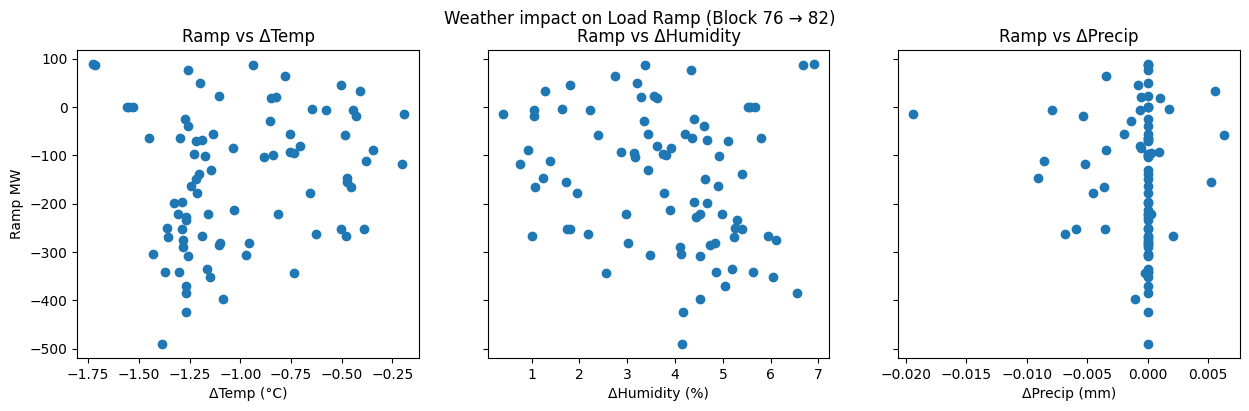

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)

axes[0].scatter(joined["dTemp"], joined["ramp_82_76"])
axes[0].set_xlabel("ΔTemp (°C)")
axes[0].set_ylabel("Ramp MW")
axes[0].set_title("Ramp vs ΔTemp")

axes[1].scatter(joined["dHumid"], joined["ramp_82_76"])
axes[1].set_xlabel("ΔHumidity (%)")
axes[1].set_title("Ramp vs ΔHumidity")

axes[2].scatter(joined["dPrecip"], joined["ramp_82_76"])
axes[2].set_xlabel("ΔPrecip (mm)")
axes[2].set_title("Ramp vs ΔPrecip")

plt.suptitle("Weather impact on Load Ramp (Block 76 → 82)")
plt.show()


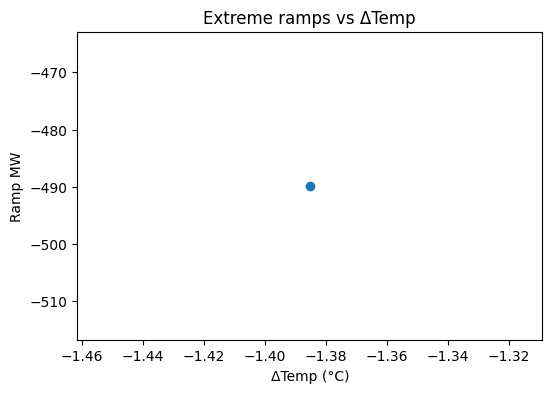

In [84]:
mu = joined["ramp_82_76"].mean()
sigma = joined["ramp_82_76"].std()

extreme = joined[(joined["ramp_82_76"] - mu).abs() > 2*sigma]

plt.figure(figsize=(6,4))
plt.scatter(extreme["dTemp"], extreme["ramp_82_76"])
plt.xlabel("ΔTemp (°C)")
plt.ylabel("Ramp MW")
plt.title("Extreme ramps vs ΔTemp")
plt.show()


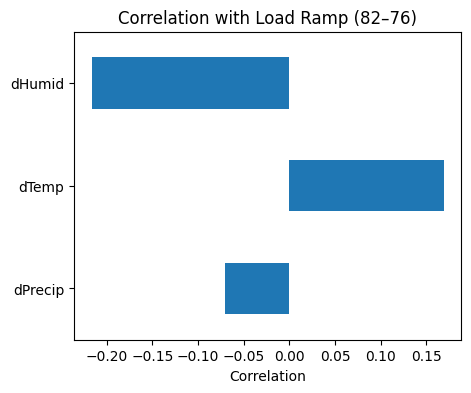

In [85]:
corr = joined[["ramp_82_76","dTemp","dHumid","dPrecip"]].corr()["ramp_82_76"].drop("ramp_82_76")

plt.figure(figsize=(5,4))
corr.sort_values(key=lambda x: abs(x)).plot(kind="barh")
plt.title("Correlation with Load Ramp (82–76)")
plt.xlabel("Correlation")
plt.show()


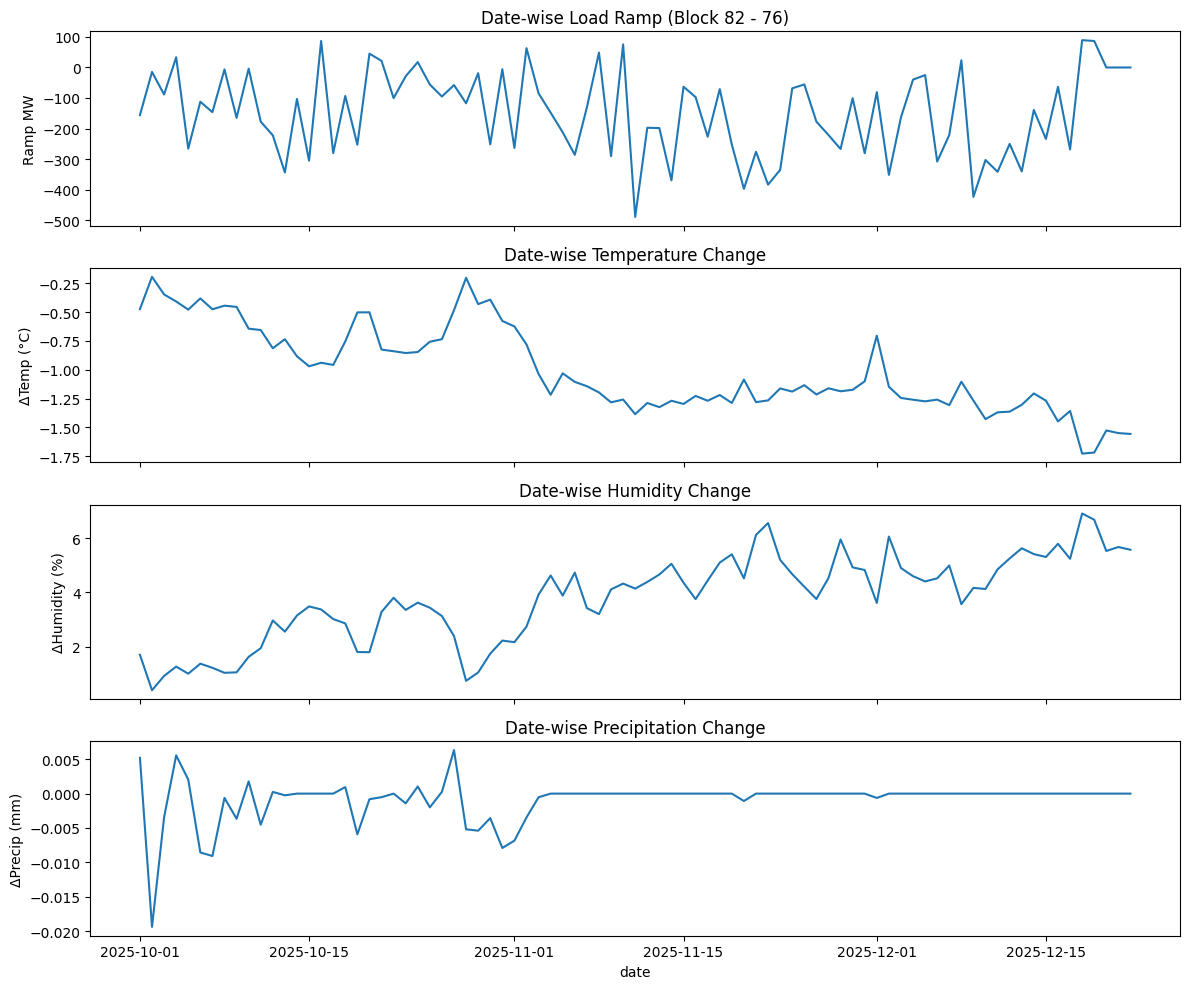

In [88]:
import matplotlib.pyplot as plt

dfp = joined.sort_values("date")

fig, ax = plt.subplots(4, 1, figsize=(12,10), sharex=True)

ax[0].plot(dfp["date"], dfp["ramp_82_76"])
ax[0].set_ylabel("Ramp MW")
ax[0].set_title("Date-wise Load Ramp (Block 82 - 76)")

ax[1].plot(dfp["date"], dfp["dTemp"])
ax[1].set_ylabel("ΔTemp (°C)")
ax[1].set_title("Date-wise Temperature Change")

ax[2].plot(dfp["date"], dfp["dHumid"])
ax[2].set_ylabel("ΔHumidity (%)")
ax[2].set_title("Date-wise Humidity Change")

ax[3].plot(dfp["date"], dfp["dPrecip"])
ax[3].set_ylabel("ΔPrecip (mm)")
ax[3].set_title("Date-wise Precipitation Change")

plt.xlabel("date")
plt.tight_layout()
plt.show()


In [89]:
kpi_baseline = {
    "mean_ramp_MW": joined["ramp_82_76"].mean(),
    "median_ramp_MW": joined["ramp_82_76"].median(),
    "p95_ramp_MW": joined["ramp_82_76"].quantile(0.95),
    "max_ramp_MW": joined["ramp_82_76"].max(),
}
kpi_baseline


{'mean_ramp_MW': np.float64(-149.17783132530118),
 'median_ramp_MW': np.float64(-139.25),
 'p95_ramp_MW': np.float64(61.879999999999804),
 'max_ramp_MW': np.float64(89.5)}

In [90]:
mu = joined["ramp_82_76"].mean()
sigma = joined["ramp_82_76"].std()

joined["is_extreme"] = (joined["ramp_82_76"] - mu).abs() > 2*sigma
print(joined['is_extreme'])

kpi_extreme = {
    "extreme_days_pct": 100 * joined["is_extreme"].mean(),
    "extreme_days_count": int(joined["is_extreme"].sum()),
    "total_days": len(joined)
}
kpi_extreme


{'extreme_days_pct': np.float64(1.2048192771084338),
 'extreme_days_count': 1,
 'total_days': 83}

In [93]:
top_days = joined.sort_values("ramp_82_76", ascending=False)\
                 .head(10)[["date","ramp_82_76","dTemp","dHumid","dPrecip"]]
top_days


,date,ramp_82_76,dTemp,dHumid,dPrecip
78,2025-12-18,89.50,-1.726501,6.906361,0.000000
79,2025-12-19,86.83,-1.717670,6.675219,0.000000
15,2025-10-16,86.83,-0.939576,3.374071,0.000000
40,2025-11-10,75.58,-1.258206,4.326607,0.000000
32,2025-11-02,63.33,-0.780770,2.741069,-0.003473
38,2025-11-08,48.83,-1.196788,3.202661,0.000000
19,2025-10-20,45.33,-0.502615,1.801995,-0.000814
3,2025-10-04,33.50,-0.408925,1.271762,0.005564
68,2025-12-08,23.42,-1.104160,3.569577,0.000000
20,2025-10-21,21.67,-0.825314,3.283827,-0.000517


In [ ]:
forecast_corrected

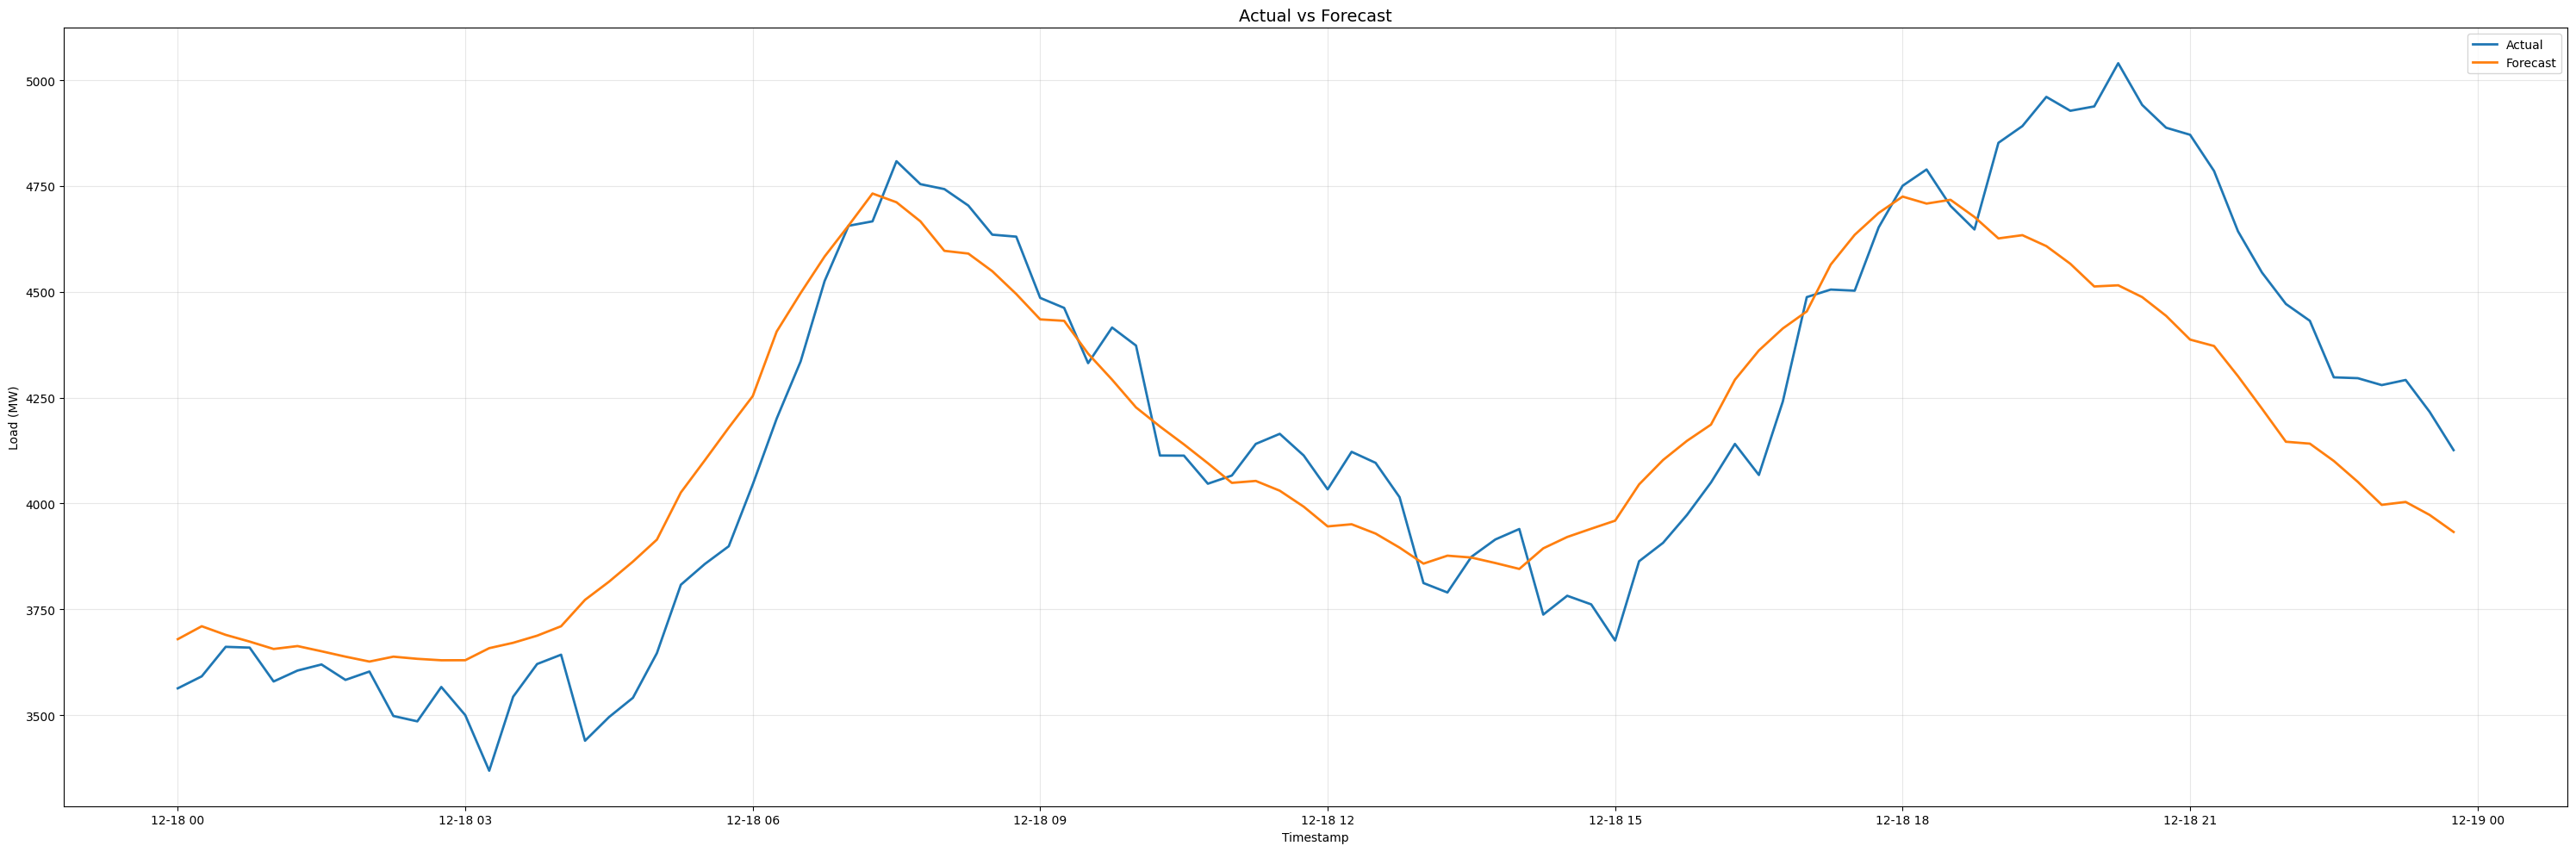

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

actual_values = [
    3563.33, 3591.67, 3661.33, 3659.5, 3579.5, 3605.33, 3619.67, 3583.25,
    3603, 3498, 3485.33, 3566.5, 3500, 3368.67, 3543.5, 3620.75, 3642.75,
    3439.5, 3495.33, 3541, 3646.5, 3808, 3857, 3899, 4044.75, 4200.5,
    4335.67, 4525.33, 4656, 4666.5, 4808.5, 4754.33, 4742.67, 4703.75,
    4635, 4630.33, 4485.67, 4462, 4331.5, 4415.67, 4373, 4113.25, 4113,
    4046.67, 4066, 4140.75, 4164.5, 4113.33, 4033.33, 4122, 4096, 4015,
    3812, 3789.75, 3874, 3915, 3939.67, 3737.5, 3782, 3761.67, 3676.33,
    3863.5, 3907, 3973, 4049.5, 4140.67, 4067.33, 4241, 4487.5, 4505.33,
    4502.67, 4652.25, 4750.5, 4789, 4703, 4647.33, 4852, 4891.5, 4960.5,
    4927.67, 4938, 5040, 4941.5, 4887.67, 4871, 4785.5, 4643, 4545.67,
    4471.33, 4431.5, 4298, 4296, 4279.67, 4291.75, 4216.5, 4126
]


actual = pd.Series(actual_values, index=forecast_corrected.index, name="Actual")

df_plot = pd.concat([actual, (forecast_corrected.rename("Forecast"))], axis=1)

plt.figure(figsize=(30, 10))
plt.plot(df_plot.index, df_plot["Actual"], label="Actual", linewidth=2)
plt.plot(df_plot.index, df_plot["Forecast"], label="Forecast", linewidth=2)
plt.title("Actual vs Forecast", fontsize=14)
plt.xlabel("Timestamp")
plt.ylabel("Load (MW)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [81]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calculate_metrics(actual, forecast):
    """
    Computes full forecast evaluation metrics.
    Inputs:q
        actual   : pd.Series
        forecast : pd.Series
    """
    mae  = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    mpe  = np.mean((forecast - actual) / actual) * 100

    metrics = pd.DataFrame({
        "MAE":  [mae],
        "MAPE (%)": [mape],
        "MPE (%)":  [mpe],
    })
    return metrics

metrics = calculate_metrics(df_plot["Actual"], df_plot["Forecast"])
print(metrics)


          MAE  MAPE (%)   MPE (%)
0  164.125235  3.905115 -0.127624


In [53]:
forecast_corrected.to_csv("forecast_odi_19.csv")

In [354]:
forecast.to_csv("forecast_11_24.csv")

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ---------------------------------------------------------
# Time Features
# ---------------------------------------------------------

def add_time_features(df):
    df = df.copy()
    idx = df.index

    df["date"] = idx.date
    df["hour"] = idx.hour
    df["minute"] = idx.minute
    df["block"] = df["hour"] * 4 + (df["minute"] // 15)
    df["dayofweek"] = idx.dayofweek
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    df["is_peak_hour"] = df["hour"].isin([18,19,20,21]).astype(int)
    df["is_offpeak_hour"] = df["hour"].isin([1,2,3,4]).astype(int)

    # Additional time derivatives
    df["load_lag_1"] = df["load"].shift(1)
    df["load_delta"] = df["load"] - df["load_lag_1"]
    df["load_ramp"] = df["load_delta"].abs()

    return df

# ---------------------------------------------------------
# New Inferential Statistics
# ---------------------------------------------------------

def ramp_rate_stats(df):
    """Quantifies grid stress and flexibility requirements."""
    daily_ramp = df.groupby("date")["load_ramp"].sum()
    return pd.DataFrame({
        "avg_ramp": daily_ramp.mean(),
        "max_ramp": daily_ramp.max(),
        "min_ramp": daily_ramp.min(),
        "ramp_volatility": daily_ramp.std()
    }, index=[0])

def peak_intensity(df):
    """Peak/Offpeak dominance metrics."""
    peak = df[df["is_peak_hour"] == 1]["load"].mean()
    off = df[df["is_offpeak_hour"] == 1]["load"].mean()
    return {
        "peak_intensity_ratio": round(peak / off, 3),
        "peak_load_mean": peak,
        "offpeak_load_mean": off
    }

def correlation_matrix(df, weather_cols=None):
    features = ["load", "hour", "dayofweek", "is_weekend", "block"]
    if weather_cols:
        features += weather_cols

    corr = df[features].corr()
    return corr

# ---------------------------------------------------------
# Descriptive Profiles / Seasonal Diagnostics
# ---------------------------------------------------------

def avg_load_by_block(df):
    return df.groupby("block")["load"].mean().rename("avg_load")

def block_volatility(df):
    return df.groupby("block")["load"].std().rename("block_volatility")

def block_ramp_profile(df):
    return df.groupby("block")["load_ramp"].mean().rename("avg_ramp")

def daily_stats(df):
    daily = (
        df.groupby("date")["load"]
          .agg(["min", "max", "mean", "std"])
          .rename(columns={"mean": "avg", "std": "volatility"})
    )
    daily["range"] = daily["max"] - daily["min"]
    return daily

def monthly_lift(df):
    df2 = df.copy()
    df2["month"] = df2.index.month
    out = df2.groupby("month")["load"].mean().pct_change() * 100
    return out.rename("mom_lift_percent")

# ---------------------------------------------------------
# Visual Suite
# ---------------------------------------------------------

def plot_avg_profile(avg_block):
    plt.figure(figsize=(14,5))
    avg_block.plot(linewidth=2)
    plt.fill_between(avg_block.index, avg_block.values, alpha=0.1)
    plt.title("Average 96-Block Load Curve")
    plt.grid(alpha=0.3)
    plt.show()

def plot_block_volatility(vol):
    plt.figure(figsize=(14,5))
    vol.plot(linewidth=2, color="red")
    plt.title("Volatility per Block (StdDev)")
    plt.grid(alpha=0.3)
    plt.show()

def plot_ramp_profile(ramp):
    plt.figure(figsize=(14,5))
    ramp.plot(linewidth=2, color="purple")
    plt.title("System Ramp Stress Curve (Avg Ramp per Block)")
    plt.grid(alpha=0.3)
    plt.show()

def plot_correlation(corr):
    plt.figure(figsize=(10,7))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()

def plot_seasonal_decompose(df):
    result = seasonal_decompose(df["load"], model="additive", period=96)
    result.plot()
    plt.suptitle("Seasonal Decomposition (Trend/Seasonality/Residual)")
    plt.show()

def plot_autocorrelation(df):
    plt.figure(figsize=(12,5))
    plot_acf(df["load"], lags=200)
    plt.title("Autocorrelation (ACF)")
    plt.show()

    plt.figure(figsize=(12,5))
    plot_pacf(df["load"], lags=200)
    plt.title("Partial Autocorrelation (PACF)")
    plt.show()

# ---------------------------------------------------------
# End-to-end enhanced EDA
# ---------------------------------------------------------

def run_full_eda(df, weather_cols=None, run_ts_diagnostics=True):
    df2 = add_time_features(df)

    # Core Stats
    avg_block = avg_load_by_block(df2)
    vol_block = block_volatility(df2)
    ramp_block = block_ramp_profile(df2)
    daily = daily_stats(df2)
    mom_lift = monthly_lift(df2)
    ramp_stats = ramp_rate_stats(df2)
    peak_idx = peak_intensity(df2)
    corr = correlation_matrix(df2, weather_cols)

    # Visualization
    plot_avg_profile(avg_block)
    plot_block_volatility(vol_block)
    plot_ramp_profile(ramp_block)
    plot_correlation(corr)

    if run_ts_diagnostics:
        plot_seasonal_decompose(df2)
        plot_autocorrelation(df2)

    print("\n=== Peak Intensity Metrics ===")
    print(peak_idx)

    print("\n=== Daily Summary ===")
    print(daily.head())

    print("\n=== Month-over-Month Lift (%) ===")
    print(mom_lift)

    print("\n=== Ramp/KPI Summary ===")
    print(ramp_stats)


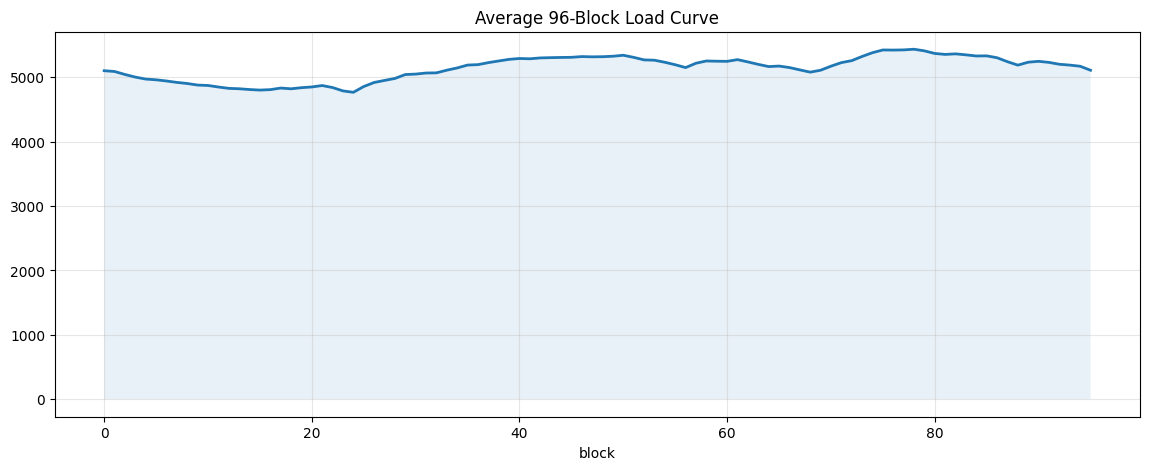

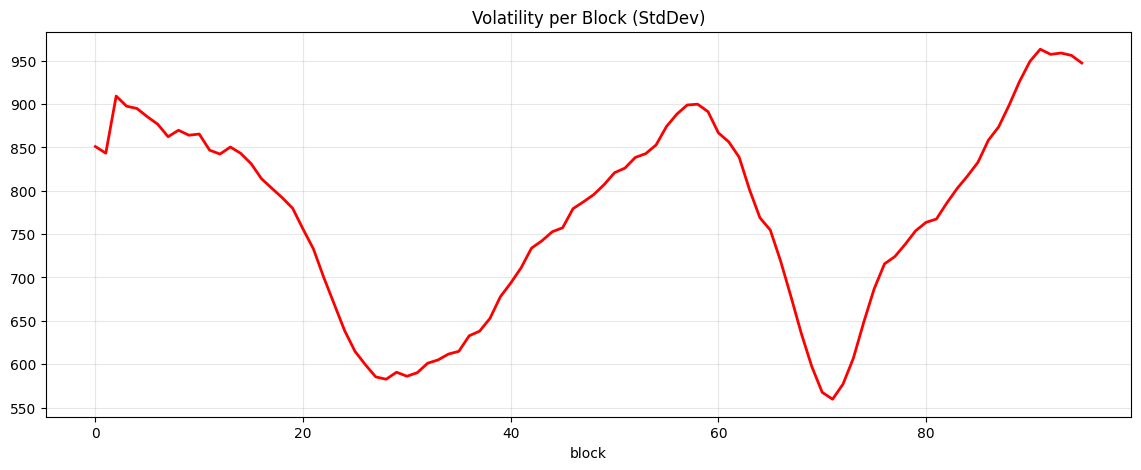

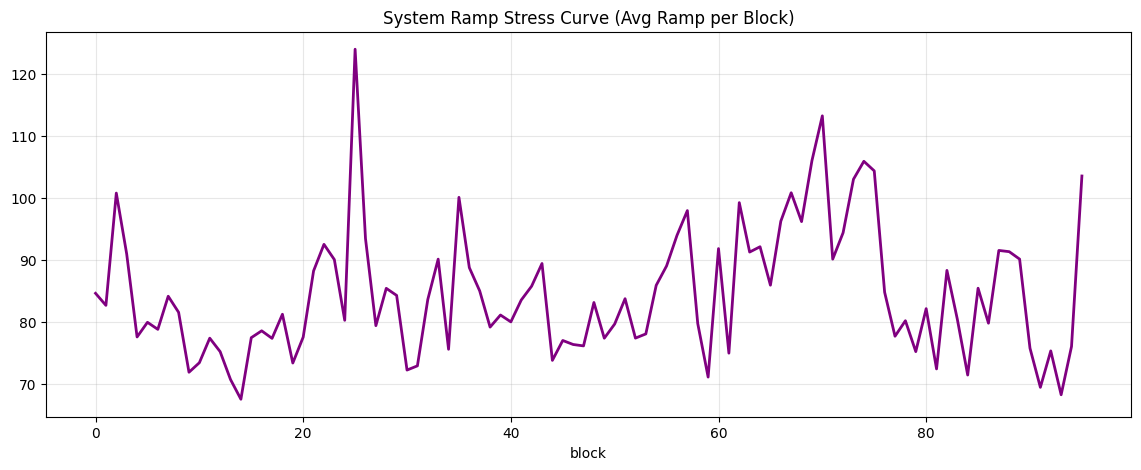

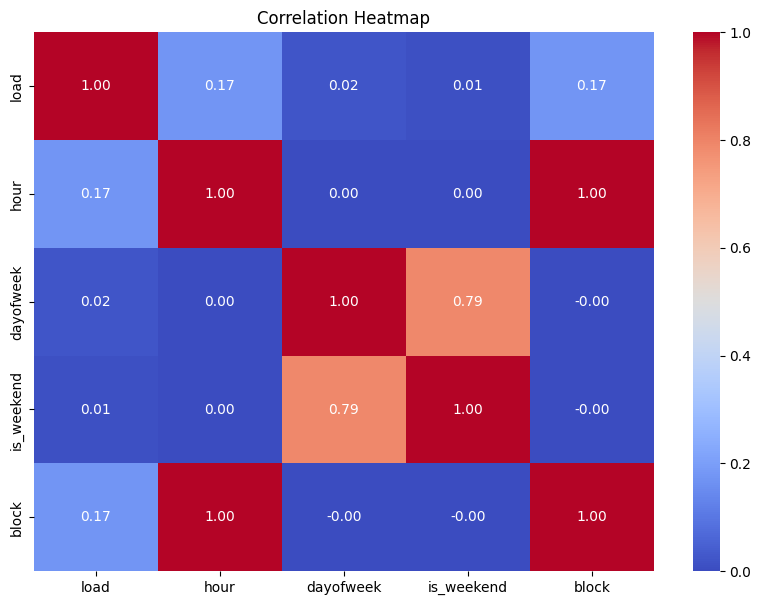

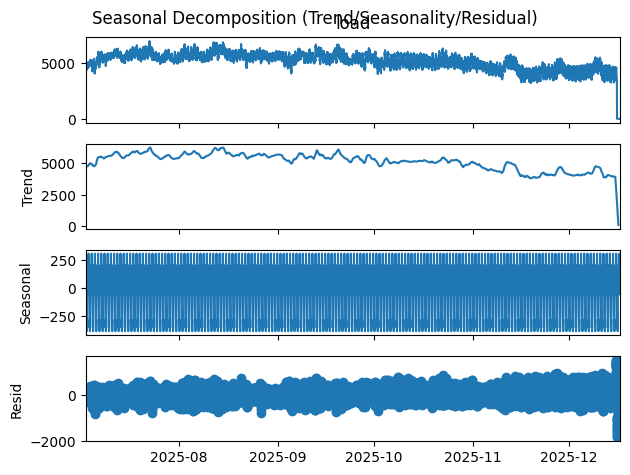

<Figure size 1200x500 with 0 Axes>

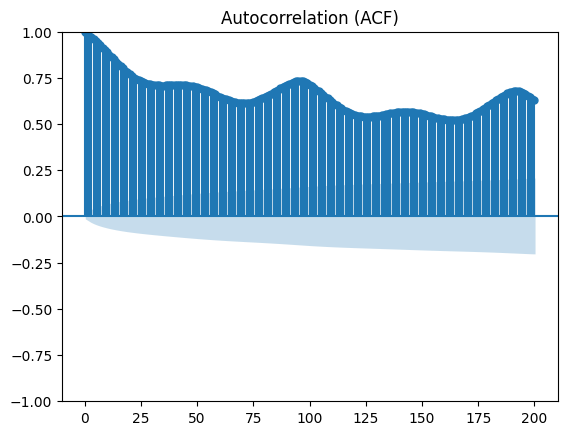

<Figure size 1200x500 with 0 Axes>

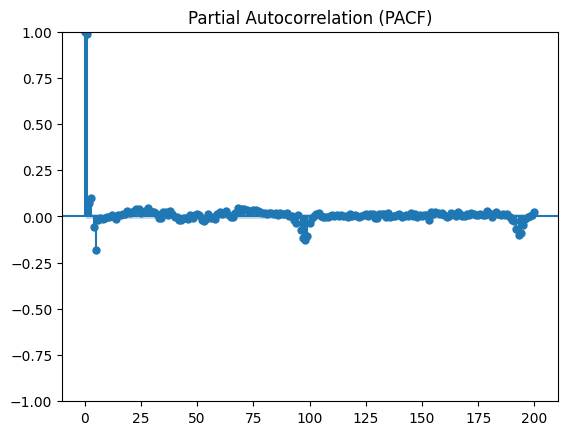


=== Peak Intensity Metrics ===
{'peak_intensity_ratio': np.float64(1.101), 'peak_load_mean': np.float64(5356.19591504491), 'offpeak_load_mean': np.float64(4864.6658383233535)}

=== Daily Summary ===
                min      max          avg  volatility    range
date                                                          
2025-07-03  4394.57  5105.15  4783.123958  157.618805   710.58
2025-07-04  4720.14  5302.57  5010.759687  129.622551   582.43
2025-07-05  4057.88  5381.00  4780.534896  297.631054  1323.12
2025-07-06  4469.62  6027.29  5304.502917  418.122419  1557.67
2025-07-07  4613.38  6030.71  5527.497500  255.485764  1417.33

=== Month-over-Month Lift (%) ===
month
7           NaN
8      2.922984
9     -4.214316
10    -6.675930
11   -14.466047
12   -10.642001
Name: mom_lift_percent, dtype: float64

=== Ramp/KPI Summary ===
      avg_ramp  max_ramp  min_ramp  ramp_volatility
0  8112.667006  13711.34   3467.33      1367.889244


In [94]:
run_full_eda(Train_df)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

class LoadAnalyticsSuite:
    """
    Enterprise-grade load analytics and diagnostic engine.
    Provides:
        - Structural demand profiling
        - Ramp stress analytics
        - Volatility diagnostics
        - Seasonality KPIs
        - Correlation intelligence
        - Forecast-readiness insights
        - Auto-inference narrative
    """

    # -----------------------------------------------------
    # Constructor
    # -----------------------------------------------------
    def __init__(self, df, load_col="load", weather_cols=None, freq=96):
        self.df_raw = df.copy()
        self.load_col = load_col
        self.freq = freq
        self.weather_cols = weather_cols or []

        # enriched dataset
        self.df = self._add_time_features(self.df_raw)

    # -----------------------------------------------------
    # Time Features
    # -----------------------------------------------------
    def _add_time_features(self, df):
        df = df.copy()
        idx = df.index

        df["date"] = idx.date
        df["hour"] = idx.hour
        df["minute"] = idx.minute
        df["block"] = df["hour"] * 4 + (df["minute"] // 15)
        df["dayofweek"] = idx.dayofweek
        df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

        df["load_lag1"] = df[self.load_col].shift(1)
        df["load_delta"] = df[self.load_col] - df["load_lag1"]
        df["load_ramp"] = df["load_delta"].abs()

        return df

    # -----------------------------------------------------
    # Core KPIs
    # -----------------------------------------------------
    def avg_load_profile(self):
        return (
            self.df.groupby("block")[self.load_col].mean()
            .rename("avg_load")
        )

    def block_volatility(self):
        return (
            self.df.groupby("block")[self.load_col].std()
            .rename("block_volatility")
        )

    def block_ramp_profile(self):
        return (
            self.df.groupby("block")["load_ramp"].mean()
            .rename("avg_ramp")
        )

    def daily_stats(self):
        daily = (
            self.df.groupby("date")[self.load_col]
                .agg(["min", "max", "mean", "std"])
                .rename(columns={"mean": "avg", "std": "volatility"})
        )
        daily["range"] = daily["max"] - daily["min"]
        return daily

    def monthly_shift(self):
        df = self.df.copy()
        df["month"] = df.index.month
        mom = df.groupby("month")[self.load_col].mean().pct_change() * 100
        return mom.rename("mom_shift")

    def peak_intensity(self):
        peak = self.df[self.df["hour"].isin([18, 19, 20, 21])][self.load_col].mean()
        offp = self.df[self.df["hour"].isin([1, 2, 3, 4])][self.load_col].mean()
        return {
            "peak_intensity_ratio": peak / offp if offp > 0 else np.nan,
            "peak_load_mean": peak,
            "offpeak_load_mean": offp
        }

    def ramp_kpis(self):
        daily_ramp = self.df.groupby("date")["load_ramp"].sum()
        return pd.DataFrame({
            "avg_ramp": [daily_ramp.mean()],
            "max_ramp": [daily_ramp.max()],
            "min_ramp": [daily_ramp.min()],
            "ramp_volatility": [daily_ramp.std()]
        })

    def correlation_matrix(self):
        cols = ["load", "hour", "dayofweek", "block", "load_delta", "load_ramp"]
        cols = [c for c in cols if c in self.df.columns]
        cols += self.weather_cols
        return self.df[cols].corr()

    # -----------------------------------------------------
    # Plotting Layer
    # -----------------------------------------------------
    def plot_profiles(self):
        avg_block = self.avg_load_profile()
        vol = self.block_volatility()
        ramp = self.block_ramp_profile()

        plt.figure(figsize=(14, 5))
        avg_block.plot()
        plt.title("Average Load Curve (96-block)")
        plt.grid(alpha=0.3)
        plt.show()

        plt.figure(figsize=(14, 5))
        vol.plot(color="red")
        plt.title("Block Volatility Curve")
        plt.grid(alpha=0.3)
        plt.show()

        plt.figure(figsize=(14, 5))
        ramp.plot(color="purple")
        plt.title("Ramp Stress Curve")
        plt.grid(alpha=0.3)
        plt.show()

    def plot_corr(self):
        corr = self.correlation_matrix()
        plt.figure(figsize=(10, 7))
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
        plt.title("Correlation Matrix")
        plt.show()

    def plot_ts_decomp(self):
        result = seasonal_decompose(self.df[self.load_col], model="additive", period=self.freq)
        result.plot()
        plt.show()

    def plot_acf_pacf(self):
        plot_acf(self.df[self.load_col].dropna(), lags=200)
        plt.show()
        plot_pacf(self.df[self.load_col].dropna(), lags=200)
        plt.show()

    # -----------------------------------------------------
    # Forecast-Readiness Intelligence (specific for LGBM)
    # -----------------------------------------------------
    def feature_recommendations(self):
        """
        Provides LGBM feature engineering guidance based on structural KPIs:
        """
        recommendations = []

        # Ramp features necessary if ramp-vol > ~800
        ramp_vol = self.ramp_kpis()["ramp_volatility"].iloc[0]
        if ramp_vol > 800:
            recommendations.append("Include Δload, Δtemp, and Δhumidity to stabilize ramp shocks.")

        # Seasonality shifts > 5% MoM
        mom = self.monthly_shift().dropna()
        if (mom.abs() > 5).any():
            recommendations.append("Introduce month, week-of-year and decomposition trend as features.")

        # High block volatility
        if self.block_volatility().mean() > 300:
            recommendations.append("Add block index, hour, and time embeddings.")

        # Weekend shift patterns
        if self.df["is_weekend"].mean() > 0.25:
            recommendations.append("Ensure is_weekend and dayofweek are included.")

        return recommendations

    # -----------------------------------------------------
    # Enterprise Narrative
    # -----------------------------------------------------
    def inference_summary(self):
        """
        Auto-generated executive commentary based on metrics.
        """
        peak = self.peak_intensity()
        ramp = self.ramp_kpis()
        mom = self.monthly_shift()

        narrative = []

        # Peak signature
        narrative.append(
            f"Load exhibits a {round((peak['peak_intensity_ratio'] - 1) * 100, 2)}% uplift "
            f"from off-peak to evening peak, signalling a structurally predictable "
            f"evening demand crest."
        )

        # Ramp commentary
        narrative.append(
            f"System ramp stress is material, with average daily ramp touching "
            f"{round(ramp['avg_ramp'].iloc[0], 1)} MW and volatility exceeding "
            f"{round(ramp['ramp_volatility'].iloc[0], 1)} MW, indicating non-trivial "
            f"intraday flexibility requirements."
        )

        # Seasonality commentary
        if mom.abs().max() > 5:
            narrative.append(
                f"Seasonality is pronounced with month-over-month shifts reaching "
                f"{round(mom.abs().max(), 2)}%, creating structural regime changes "
                f"that must be explicitly modeled."
            )
        else:
            narrative.append("Seasonality remains modest without disruptive MoM structural shifts.")

        return "\n".join(narrative)

    # -----------------------------------------------------
    # Master Execution
    # -----------------------------------------------------
    def run_all(self, run_plots=False, run_ts=True):
        print("\n=== Peak Metrics ===")
        print(self.peak_intensity())

        print("\n=== Daily KPIs ===")
        print(self.daily_stats().head())

        print("\n=== Ramp KPIs ===")
        print(self.ramp_kpis())

        print("\n=== Seasonality (MoM shift %) ===")
        print(self.monthly_shift())

        print("\n=== Feature Recommendations for LGBM ===")
        print(self.feature_recommendations())

        print("\n=== Executive Summary ===")
        print(self.inference_summary())

        if run_plots:
            self.plot_profiles()
            self.plot_corr()
        if run_ts:
            self.plot_ts_decomp()
            self.plot_acf_pacf()



=== Peak Metrics ===
{'peak_intensity_ratio': np.float64(1.2418569445191225), 'peak_load_mean': np.float64(6837.589413265306), 'offpeak_load_mean': np.float64(5505.939668367348)}

=== Daily KPIs ===
                min      max          avg  volatility    range
date                                                          
2025-10-15  6094.33  9189.16  7854.706354  897.454806  3094.83
2025-10-16  6089.55  9139.36  7816.445000  845.224747  3049.81
2025-10-17  6141.77  9252.35  7945.873437  828.829370  3110.58
2025-10-18  6770.25  8952.92  7778.425938  584.890249  2182.67
2025-10-19  6046.79  8121.68  7203.593333  471.288612  2074.89

=== Ramp KPIs ===
       avg_ramp  max_ramp  min_ramp  ramp_volatility
0  10253.508776  13276.17   7499.61      1035.453498

=== Seasonality (MoM shift %) ===
month
10         NaN
11   -8.046971
12    6.658303
Name: mom_shift, dtype: float64

=== Feature Recommendations for LGBM ===
['Include Δload, Δtemp, and Δhumidity to stabilize ramp shocks.', 'Introdu

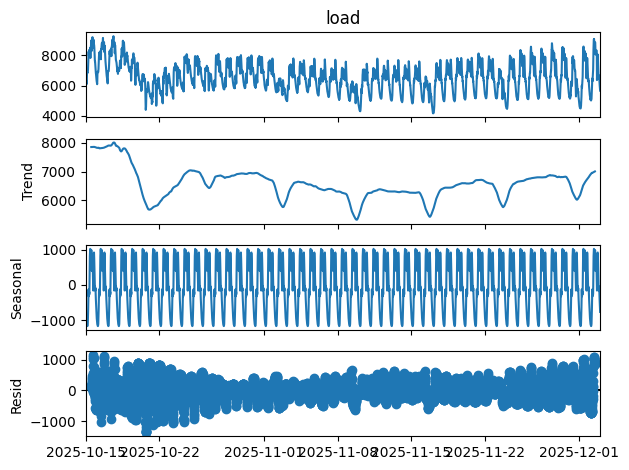

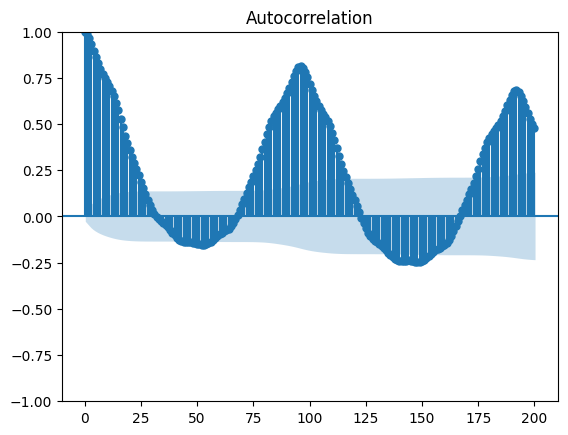

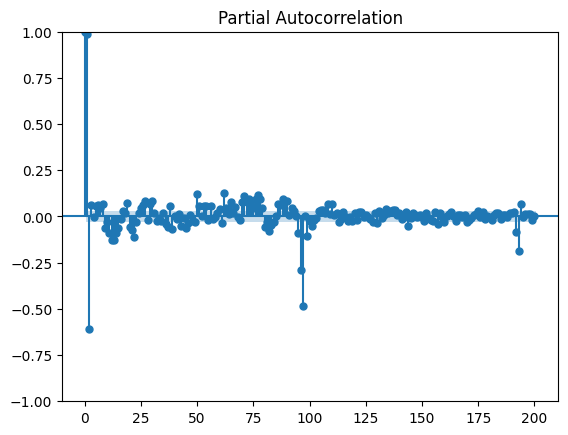

In [21]:
LoadAnalyticsSuite(train_df).run_all()

In [22]:
print(train_df)

                        load  temperature   humidity  precipitation  \
Datetime                                                              
2025-10-15 00:00:00  6368.12    20.616802  71.417624            0.0   
2025-10-15 00:15:00  6333.38    20.555604  71.591969            0.0   
2025-10-15 00:30:00  6274.68    20.494406  71.766314            0.0   
2025-10-15 00:45:00  6236.08    20.433208  71.940659            0.0   
2025-10-15 01:00:00  6157.84    20.372011  72.115003            0.0   
...                      ...          ...        ...            ...   
2025-12-02 22:45:00  6001.33    11.553069  80.694661            0.0   
2025-12-02 23:00:00  5878.45    11.330834  81.195803            0.0   
2025-12-02 23:15:00  5818.32    11.111345  81.629020            0.0   
2025-12-02 23:30:00  5748.15    10.891856  82.062236            0.0   
2025-12-02 23:45:00  5664.59    10.672367  82.495453            0.0   

                     is_weekend  hour  minute  day_of_week  day_of_month  \


In [27]:
import numpy as np
import pandas as pd

def correct_forecast_seasonal_weather(test_df, forecast, temp_col="temperature"):
    """
    Seasonally-adaptive weather elasticity correction.
    Works WITHOUT actual load.
    Only uses:
       - temperature
       - month (season)
       - forecast direction vs expected direction
    
    Returns:
        corrected_forecast
        diagnostics
    """
    df = test_df.copy()
    df["forecast"] = forecast

    # =====================================================
    # 1. Identify Season (India context but adjustable)
    # =====================================================
    # You can tune or extend seasons easily
    month = df.index.month

    df["season"] = "neutral"

    df.loc[month.isin([4,5,6,7]), "season"] = "summer"   # cooling dominant
    df.loc[month.isin([11,12,1,2]), "season"] = "winter" # heating dominant

    # (Aug–Oct, Mar are neutral transition months)

    # =====================================================
    # 2. Elasticity rules by season
    # =====================================================

    df["elasticity"] = 0.0

    # ------------------------
    # SUMMER: temp ↑ ⇒ load ↑
    # ------------------------
    cooling_thr = 24
    summer_mask = df["season"] == "summer"
    
    df.loc[
        summer_mask & (df[temp_col] > cooling_thr),
        "elasticity"
    ] = +0.035 * (df[temp_col] - cooling_thr)

    df.loc[
        summer_mask & (df[temp_col] < cooling_thr),
        "elasticity"
    ] = -0.020 * (cooling_thr - df[temp_col])

    # ------------------------
    # WINTER: temp ↓ ⇒ load ↑
    # ------------------------
    heating_thr = 18
    winter_mask = df["season"] == "winter"

    df.loc[
        winter_mask & (df[temp_col] < heating_thr),
        "elasticity"
    ] = +0.030 * (heating_thr - df[temp_col])

    df.loc[
        winter_mask & (df[temp_col] > heating_thr),
        "elasticity"
    ] = -0.018 * (df[temp_col] - heating_thr)

    # ------------------------
    # NEUTRAL SEASON
    # ------------------------
    # Do not apply strong corrections — keep elasticity near 0
    df.loc[df["season"] == "neutral", "elasticity"] *= 0.25

    # =====================================================
    # 3. Detect Direction Mismatch  
    # (no actual load needed)
    # =====================================================
    df["temp_dir"] = np.sign(df[temp_col].diff())
    df["fcst_dir"] = np.sign(df["forecast"].diff())

    df["mismatch"] = (
        (df["temp_dir"] > 0) & (df["fcst_dir"] < 0) |
        (df["temp_dir"] < 0) & (df["fcst_dir"] > 0)
    ).astype(int)

    # Only correct when mismatch detected
    df["correction_factor"] = 1 + 0.6 * df["elasticity"]
    df["correction_factor"] = np.where(
        df["mismatch"] == 1, 
        df["correction_factor"],
        1.0
    )

    # =====================================================
    # 4. Apply Correction with Hard Caps
    # =====================================================
    df["forecast_corrected"] = df["forecast"] * df["correction_factor"]

    # Cap +/-15% to avoid instability
    df["forecast_corrected"] = np.minimum(df["forecast_corrected"], df["forecast"] * 1.15)
    df["forecast_corrected"] = np.maximum(df["forecast_corrected"], df["forecast"] * 0.85)

    diagnostics = df[
        [
            temp_col, "season", "forecast", "forecast_corrected",
            "elasticity", "correction_factor", "mismatch"
        ]
    ]
    return df["forecast_corrected"], diagnostics


In [29]:
corrections,diag = correct_forecast_seasonal_weather(test_df,forecast)

In [35]:
corrections.to_csv("correction.csv")

In [41]:
print(diag.head(96))

                     temperature  season     forecast  forecast_corrected  \
Datetime                                                                    
2025-12-03 00:00:00    10.452879  winter  5368.705279         5368.705279   
2025-12-03 00:15:00    10.299670  winter  5314.374767         5314.374767   
2025-12-03 00:30:00    10.146462  winter  5272.011606         5272.011606   
2025-12-03 00:45:00     9.993253  winter  5231.048191         5231.048191   
2025-12-03 01:00:00     9.840045  winter  5150.755023         5150.755023   
...                          ...     ...          ...                 ...   
2025-12-03 22:45:00    10.543551  winter  5961.808536         5961.808536   
2025-12-03 23:00:00    10.456748  winter  5831.984947         5831.984947   
2025-12-03 23:15:00    10.456748  winter  5784.160392         5784.160392   
2025-12-03 23:30:00    10.456748  winter  5700.513811         5700.513811   
2025-12-03 23:45:00    10.456748  winter  5620.834520         5620.834520   